<a href="https://colab.research.google.com/github/AbdulWahab-14/vortextech-aiml-week3/blob/main/Week3_Regression_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Regression Model (Linear Regression on House Prices)**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load California Housing Dataset
data = fetch_california_housing(as_frame=True)
df = data.frame

# Define features (X) and continuous target (y)
X_reg = df.drop(columns=['MedHouseVal'])
y_reg = df['MedHouseVal']

# 2. Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

# 3. Train Model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# 4. Predict & Evaluate
y_pred = reg_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- Regression Results ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

--- Regression Results ---
Root Mean Squared Error (RMSE): 0.7456
R² Score: 0.5758


**Clustering Model (Elbow Method & K-Means)**

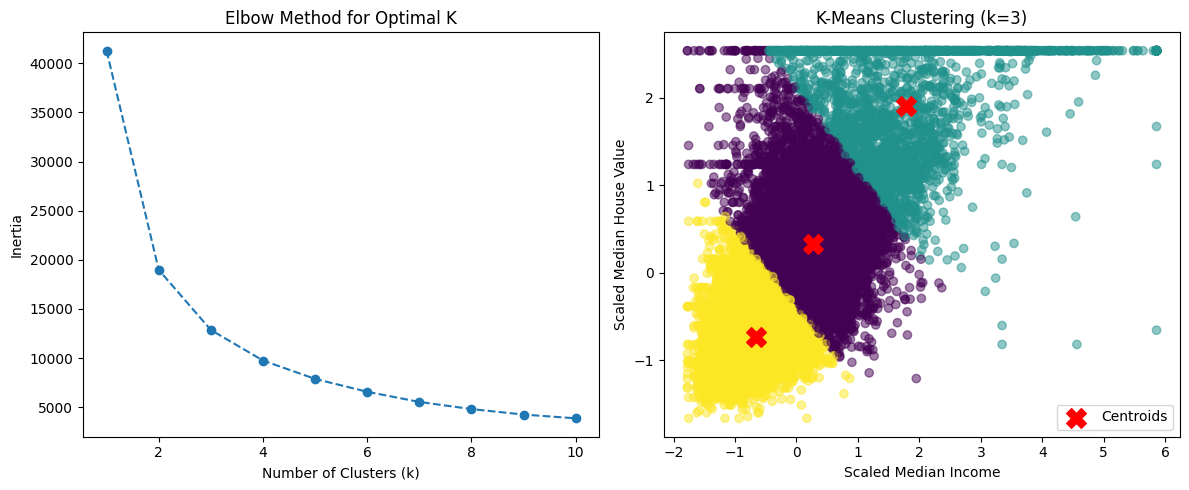

In [2]:
# 1. Select numeric features for 2D visualization & Scale them
cluster_features = df[['MedInc', 'MedHouseVal']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

# 2. Elbow Method to find optimal K
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')

# 3. Fit Final K-Means Model (Chosen K = 3)
chosen_k = 3
final_kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_scaled)

# 4. Visualize Clusters in 2D
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=cluster_labels, cmap='viridis', alpha=0.5)
plt.scatter(final_kmeans.cluster_centers_[:, 0], final_kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroids')
plt.title(f'K-Means Clustering (k={chosen_k})')
plt.xlabel('Scaled Median Income')
plt.ylabel('Scaled Median House Value')
plt.legend()

plt.tight_layout()
plt.show()